In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import os, sys
from astropy.io import fits

from scipy import interpolate

sys.path.append('..')

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

In [2]:
from utils.cart import to_cart
from utils.data_processing import get_GC_data, downsample

In [3]:
from common import TemplateWithEnergy, Exposure

## 1. get unexposed templates

### 1.1 ccwa

In [4]:
extent_pad = 25 # [deg] | Semi-extent | pad stands for padded
pixelsize_pad = 0.5 # [deg]
n_pixels_pad = int(2 * extent_pad / pixelsize_pad)
pixel_centers_pad = np.linspace(-extent_pad, extent_pad, n_pixels_pad, endpoint=False) + pixelsize_pad / 2

In [5]:
for tag in ['ccwapibrem', 'ccwaics', 'ccwaOLDpibrem', 'ccwaOLDics']: # map are with pixel size 1 degree

    hdul = fits.open(f"/zfs/nrodd/GalPropMap/Models/{tag}.fit")

    engs = hdul[1].data['ENERGY'] # [MeV]
    n_engs = len(engs)

    extent_lr = 25  # [deg] | Semi-extent | lr stands for low resolution
    pixelsize_lr = 1 # [deg]
    n_pixels_lr = int(2 * extent_lr / pixelsize_lr)
    pixel_centers_lr = np.linspace(-extent_lr, extent_lr, n_pixels_lr, endpoint=False) + pixelsize_lr / 2

    temp_pad_arr = np.zeros((n_engs, n_pixels_pad, n_pixels_pad))
    for i_e in range(n_engs):

        ## 1. piece together low res map
        temp_lr = np.zeros((n_pixels_lr, n_pixels_lr)) # -25 deg to 25 deg
        r = int(extent_lr / pixelsize_lr) # half extent pixel count
        b_c = 90 # index of pixel to the 'right' of the center edge (b=0) | 90 because of 90 degrees / 1 degree
        for l_i in range(r): # right half
            temp_lr[:, r+l_i] = hdul[0].data[i_e, b_c-r:b_c+r, l_i] # right half
        for l_i in range(r): # left half
            temp_lr[:, l_i] = hdul[0].data[i_e, b_c-r:b_c+r, -r+l_i] # left half

        ## 2. upsample (to padded)
        temp_lr_interp = interpolate.interp2d(pixel_centers_lr, pixel_centers_lr, temp_lr)
        temp_pad_arr[i_e] = temp_lr_interp(pixel_centers_pad, pixel_centers_pad)
        
        ## 3. flip horizontally
        temp_pad_arr[i_e] = np.fliplr(temp_pad_arr[i_e])
        
    temp = TemplateWithEnergy(engs=engs, templates=temp_pad_arr)
    temp.save(f'data/templates/{tag}.p')

    print(tag, end=' ')

ccwapibrem ccwaics ccwaOLDpibrem ccwaOLDics 

### 1.2 ccwf & p6v11: maps with pixel size 0.5 degree

In [12]:
file_dict = {
    'ccwfpibrem': '/zfs/nrodd/GalPropMap/Models/ccwfpibrem.fit',
    'ccwfics':    '/zfs/nrodd/GalPropMap/Models/ccwfics.fit',
    'p6v11':      '/zfs/tslatyer/galactic/fermi/diffusemodel/gll_iem_v02_P6_V11_DIFFUSE.fit'
}

for tag, filename in file_dict.items():

    print(tag)
    
    hdul = fits.open(filename)
    engs = hdul[1].data['ENERGY'] # [MeV]
    n_engs = len(engs)

    temp_pad_arr = get_GC_data(hdul[0], extent_pad, verbose=True)
    temp_pad_arr = np.array([np.fliplr(t) for t in temp_pad_arr])
    temp = TemplateWithEnergy(engs=engs, templates=temp_pad_arr)
    temp.save(f'data/templates/{tag}.p')

ccwfpibrem
get_GC_data: l: [310:410]
get_GC_data: b: [130:230]
ccwfics
get_GC_data: l: [310:410]
get_GC_data: b: [130:230]
p6v11
get_GC_data: l: [310:410]
get_GC_data: b: [130:230]


## 2. get gtsrcmaps processed maps
ccw[a/f][ics/pibrem]_573weeks_gtsrcmaps \
p6v11_573weeks_gtsrcmaps

In [ ]:
for name in ['p6v11', 'ccwaics', 'ccwapibrem', 'ccwfics', 'ccwfpibrem']:
    
    print(name)
    
    DIR = '/zfs/tslatyer/fermidata/diffusemodel/pass8_573weeks'
    hdul = fits.open(f'{DIR}/diffuse_model_map_{name}_ultracleanveto_bestpsf_joined.fits')
    hdul_eng = fits.open(f'{DIR}/diffuse_model_map_{name}_ultracleanveto_bestpsf_halfsky1.fits')
    i_eng_start = np.searchsorted(hdul_eng[2].data['E_MIN'], 2e6)
    i_eng_endp1 = np.searchsorted(hdul_eng[2].data['E_MIN'], 2e7) + 1
    temp = get_GC_data(hdul[0], 20, verbose=True)
    temp = (temp[i_eng_start:i_eng_endp1-1] + temp[i_eng_start+1:i_eng_endp1]) / 2 # algebraic average
    temp = downsample(np.sum(temp, axis=0), int(0.5/0.1))
    np.save(f'data/templates_573weeks/{name}_gtsrcmaps.npy', temp)

## 3. expose templates with kingpsf (custom gtsrcmaps)
ccw[a/f][ics/pibrem]_[exp]_kingpsf

In [15]:
#exposure_name = '573weeks'
exposure_name = '718weeks'
eng_exposure = np.logspace(np.log10(2e3), np.log10(2e4), 21)[1::2] # [MeV]
exposure_images = np.load(f'data/fermidata/exposure_{exposure_name}.npy')
exposure = Exposure(eng_exposure, exposure_images)

In [16]:
for name in ['ccwaics', 'ccwapibrem', 'ccwfics', 'ccwfpibrem', 'p6v11']:
    tempwe = TemplateWithEnergy(file=f'data/templates/{name}.p')
    temp = exposure.expose(tempwe, psf_smooth=True)
    np.save(f'data/templates_{exposure_name}/{name}_kingpsf.npy', temp)

## 4. Get Model O from healpix

In [4]:
import healpy as hp

In [5]:
for t in ['pibrem', 'ics']:
    temp_hp = np.load(f'../data/fermi_data_573w/fermi_data_256/template_O{t[:2]}.npy')

    extent = 20 # [deg]
    pixel_size = 0.5 # [deg]

    l_edge_s = np.linspace(-extent, extent, int(2*extent/pixel_size+1))
    b_edge_s = np.linspace(-extent, extent, int(2*extent/pixel_size+1))
    l_s = (l_edge_s[1:] + l_edge_s[:-1]) / 2
    b_s = (b_edge_s[1:] + b_edge_s[:-1]) / 2
    l_grid, b_grid = np.meshgrid(l_s, b_s)

    temp = hp.pixelfunc.get_interp_val(temp_hp, l_grid, b_grid, lonlat=True)
    temp /= np.mean(temp)
    temp = np.fliplr(temp)
    np.save(f'data/templates_573weeks/modelO{t}_gtsrcmaps.npy', temp)

## 5. visualize

In [41]:
ccwfpibrem = TemplateWithEnergy(file='data/templates/ccwfpibrem.p')

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.log(ccwfpibrem.templates[0]), extent=(20, -20, -20, 20))
ax.add_patch(mpl.patches.Rectangle((-20,-20), 40, 40, fc=(0,0,0,0), ec='w'))
ax.set(title=' ', xlabel='l [deg]', ylabel='b [deg]');

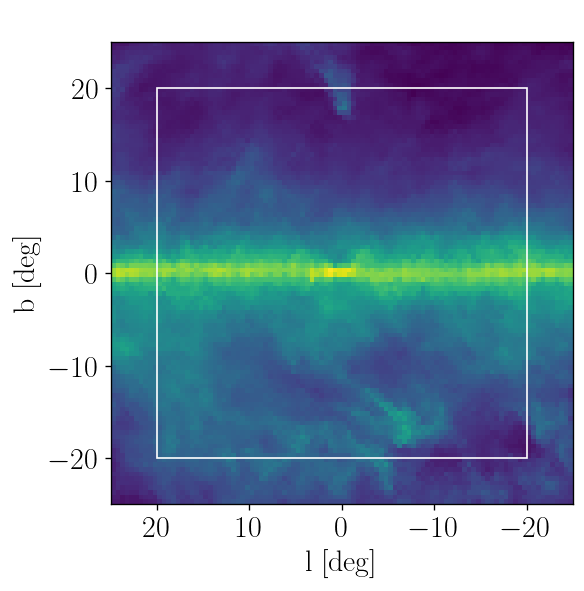

In [44]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.log(ccwfpibrem.templates[0]), extent=(25, -25, -25, 25))
ax.add_patch(mpl.patches.Rectangle((-20,-20), 40, 40, fc=(0,0,0,0), ec='w'))
ax.set(title=' ', xlabel='l [deg]', ylabel='b [deg]');

# Appendix

## SkyFACT (not done)

RoI is $|l|\le90^\circ$ and $|b|\le20.25^\circ$. \
Pixel size is $0.5^\circ$, image shape is (81, 360).

### 3.1 Pixel area map
Our RoI is $|l|<20^\circ$ and $|b|<20^\circ$ with pixel size of $0.5^\circ$.

In [13]:
theta_edges = np.linspace(70*np.pi/180, 110*np.pi/180, 81)
theta_ints = np.cos(theta_edges[:-1]) - np.cos(theta_edges[1:])
pixel_area_map = np.array([theta_int * np.full((80,), 0.5*np.pi/180) for theta_int in theta_ints])
print(f'{np.max(pixel_area_map):.3e}, {np.min(pixel_area_map):.3e}')

7.615e-05, 7.167e-05


In [14]:
names = ['ICS', 'pi0ii', 'pi0i', 'pi0o']
names_paper = ['ICS', 'Gas_ring_I', 'Gas_ring_II', 'Gas_ring_III']